<a href="https://colab.research.google.com/github/smatt27/Aprendizaje-IA-Finanzas/blob/main/RobotInversos(Base).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

class RobotInversionista:
    def __init__(self, usuario, saldo, riesgo):
        self.usuario = usuario
        self._saldo = saldo #Variable privada
        self.perfil_riesgo = riesgo
        self.meta = saldo * 1.2

    def obtener_saldo(self):
        return f"El saldo actual de {self.usuario} es {self._saldo}€"

    def depositar(self, cantidad):
        self._saldo += cantidad
        return f"Depósito exitoso. Nuevo saldo: {self._saldo}€"

    def retirar(self, cantidad):
        if cantidad > self._saldo:
            return "Fondos insuficientes"
        self._saldo -= cantidad
        return f"Retiro completado. Saldo restante: {self._saldo}€"

    def aplicar_rendimiento_pro(self, rendimientos):
        # Se convierte en array por si se pasa una lsita simple.
        rend_array = np.array(rendimientos)
        factor_total = np.prod(1 + rend_array)
        self._saldo *= factor_total
        return f"Saldo tras mercado: {round(self._saldo, 2)}€"

mi_bot = RobotInversionista("Matt", 1000, "Alto")
print(mi_bot.obtener_saldo())
print(mi_bot.retirar(500))

# Simulación de semana de mercado
movimientos_semana = [0.02, -0.01, 0.05, 0.03, -0.02]
print(mi_bot.aplicar_rendimiento_pro(movimientos_semana))


El saldo actual de Matt es 1000€
Retiro completado. Saldo restante: 500€
Saldo tras mercado: 535.13€


In [ ]:
import numpy as np
import pandas as pd

# matriz (5 días, 3 acciones) Apple[0], Google[1],Amazon[2]
precios = np.array([
    [150, 2800, 3300], # Lunes
    [152, 2810, 3290], # Martes
    [149, 2790, 3310], # Miércoles
    [155, 2850, 3350], # Jueves
    [160, 2900, 3400]  # Viernes
])

#print(precios.shape) #Muestra las cantidad de filas/columnas de la matriz

#Primer metodo
#precios = precios.mean(axis=0) Calcula el precio promedio por semana axis = 0 calcula por columna y si es igual a 1 calcula por fila
#Apple = precios[:,0] Sirve para seleccionar [filta las filas (En este caso de todos lod días) : Columnas(En este caso el indice de la acción que nos interesa)]
#mascara = precios > 2900 Filtra los precios
#rendimientos = np.array([0.02, -0.01, 0.04, -0.03, 0.01])
#resultado = np.where(rendimientos > 0, "GANANCIA", "PÉRDIDA")
#print(resultado)


#Segundo metodo
# Convertimos la matriz de NumPy en una tabla de Pandas
df = pd.DataFrame(precios, columns=['AAPL', 'GOOGL', 'AMZN'])

# Filtro dinámico por nombre
accion = 'GOOGL'
resultado = df[df[accion] > 2800][accion]

print(resultado)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

datos ={
    'Fecha': ['2023-10-01', '2023-10-02', '2023-10-03'],
    'AAPL': [150.2, 151.5, 149.8],
    'TSLA': [240.5, 238.1, 245.2],
    'Operacion': ['Compra', 'Manten', 'Venta']
}

df_datos = pd.DataFrame(datos)
#Utilizamos la fecha como indice
df_datos.set_index("Fecha", inplace=True) #Con inplace se evita hacer copia de la tabla y se modficia directamente de la memoria

print(df_datos)
#df.describe()
#df_datos.loc[:,"TSLA"] Muestra los datos usandoa etiquetas iloc[etiqueta_fila(desde:hasta),etiqueta_columna]
#df_datos.iloc[1] Muestra los datos del indice 1 de la tabla. iloc[filas(desde:hasta),columnas]

df_datos["Total_acciones"] = df_datos['AAPL'] + df_datos['TSLA'] #Se crrea una columna sumando las acciones que tenemos
#df_datos[df_datos['Total_acciones'] > 300] Muestra las accines arriba de 300
df_datos["Cambio_AAPL"] = df_datos["AAPL"].pct_change() #Se hace una columna donde se calcula el cambio porcentual de la acción AAPL con pct_change()
print(df_datos['Cambio_AAPL'])
df_datos['Cambio_AAPL'].dropna(inplace=True) #Elimina los valores NaN. COn inplace le decimos que en vez de devolver una tabla nueva sin los valores NaN, directametne que los borre sobre la orginal.

df_datos['Cambio_AAPL'].plot(kind='bar', color='green', title='Rendimiento Diario')



#  Creando el gráfico con dos columnas para comparar acciones
df_datos[['AAPL', 'TSLA']].plot(figsize=(10, 5), grid=True) #Grid nos pone el grafico en cuadriculas para comparaciones mas precisas

# 2. Personalizamos (La "estética" profesional)
plt.title('Duelo de Gigantes: Apple vs Tesla', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Precio en €')
plt.legend(['Apple', 'Tesla']) # Para saber qué color es cuál
plt.show()
# Usamos bins=10 para dividir los datos en 10 "cajitas" o columnas
df_datos['Cambio_AAPL'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')

plt.title('Distribución de Rendimientos (Apple)')
plt.xlabel('Rango de Variación (0.01 = 1%)')
plt.ylabel('Cantidad de Días')
plt.grid(axis='y', alpha=0.3) # Líneas suaves solo horizontales
plt.show()# Usamos bins=10 para dividir los datos en 10 "cajitas" o columnas


--- Reporte de Matt-Bot ---
Estado del mercado: BAJADA (Vender)
                Precio
2024-01-26  142.046442
2024-01-27  139.744455
2024-01-28  140.495851
2024-01-29  139.294574
2024-01-30  138.711186


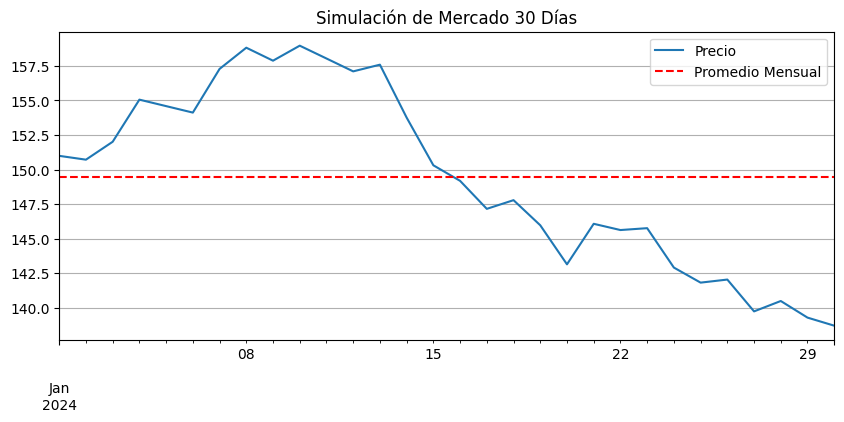

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. ARQUITECTURA
class AlphaBot:
    def __init__(self, nombre, saldo_inicial):
        self.nombre = nombre
        self._saldo = saldo_inicial
        self.historico_saldo = []

    def predecir_movimiento(self, precios):
        #Si el precio actual es mayor al promedio de los últimos 5 días, COMPRA.
        promedio_reciente = np.mean(precios[-5:]) #Preferible usar 5 días en este caso porque si bien 10 sería un promedío mas estable, en este caso buscamos analizar el mercado rapidamente frente a los cambios del mercado. En un cambio brusco usar 10 días nos produciria un lag
        precio_actual = precios[-1]
        #Aca se usa la logica de momentum si el precio esta arriba de su promedio se asume que la tendencia es alcista
        if precio_actual > promedio_reciente:
            return "SUBIDA (Comprar)"
        else:
            return "BAJADA (Vender)"


# 2. GENERACIÓN DE DATOS - Un mes de bolsa
np.random.seed(42) # Para que a ambos nos salgan los mismos números
dias = 30
precios_simulados = 150 + np.cumsum(np.random.randn(dias) * 2) #.consum para que no nos salgan números al azar, sino numeros cercanos donde el número depende un pco del ayer.

# 3. ORGANIZACIÓN
df = pd.DataFrame({
    'Precio': precios_simulados
}, index=pd.date_range(start='2024-01-01', periods=dias))

# 4. EJECUCIÓN
bot = AlphaBot("Matt-Bot", 1000)

# Predicción para el día 31
prediccion = bot.predecir_movimiento(df['Precio'].values)

print(f"--- Reporte de {bot.nombre} ---")
print(f"Estado del mercado: {prediccion}")
print(df.tail()) # Se ven los últimos días

# 5. VISUALIZACIÓN
df['Precio'].plot(figsize=(10,4), title="Simulación de Mercado 30 Días", grid=True)
plt.axhline(y=np.mean(df['Precio']), color='r', linestyle='--', label='Promedio Mensual')
plt.legend()
plt.show()